# 03 · Analyse Exploratoire des Données (EDA)
## CEET Smart Grid – Energy Blackout Prediction
**Objectif :** Comprendre les patterns de consommation, les pics de charge et les facteurs de risque.

In [5]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from utils import DATA_PROC, FIGURES

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

df = pd.read_csv(DATA_PROC / 'ceet_processed.csv', parse_dates=['datetime'])
print(f"Dataset chargé : {df.shape}")

Dataset chargé : (50000, 75)


### 3.1 Distribution Globale de la Charge

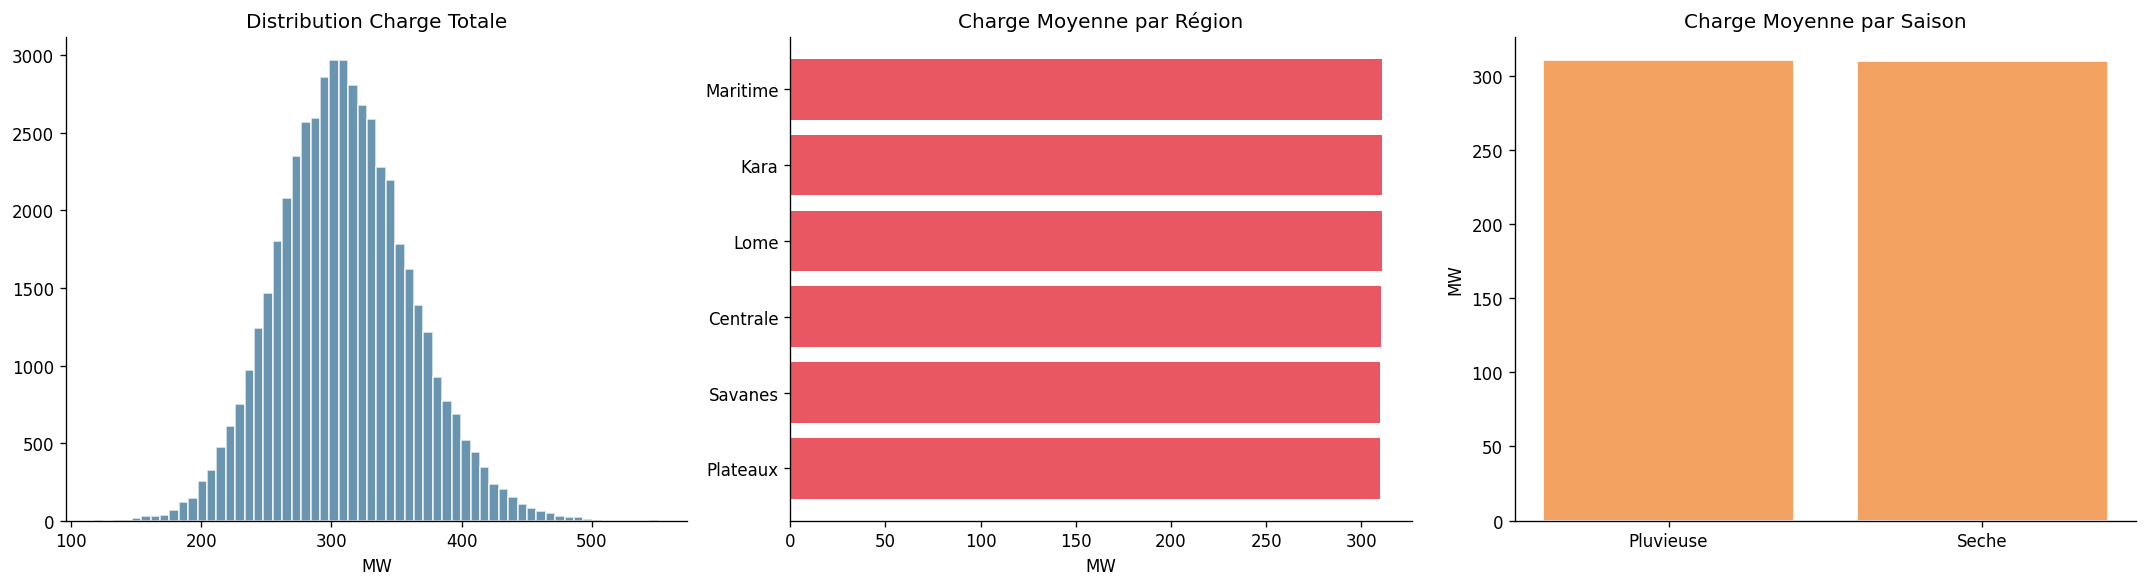

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Distribution
axes[0].hist(df['total_load_mw'], bins=60, color='#457B9D', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution Charge Totale')
axes[0].set_xlabel('MW')

# Par région
region_load = df.groupby('region')['total_load_mw'].mean().sort_values()
axes[1].barh(region_load.index, region_load.values, color='#E63946', alpha=0.85)
axes[1].set_title('Charge Moyenne par Région')
axes[1].set_xlabel('MW')

# Par saison
season_load = df.groupby('season')['total_load_mw'].mean()
axes[2].bar(season_load.index, season_load.values, color='#F4A261', edgecolor='white')
axes[2].set_title('Charge Moyenne par Saison')
axes[2].set_ylabel('MW')

plt.tight_layout()
plt.savefig(FIGURES / 'eda_load_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

### 3.2 Patterns Temporels

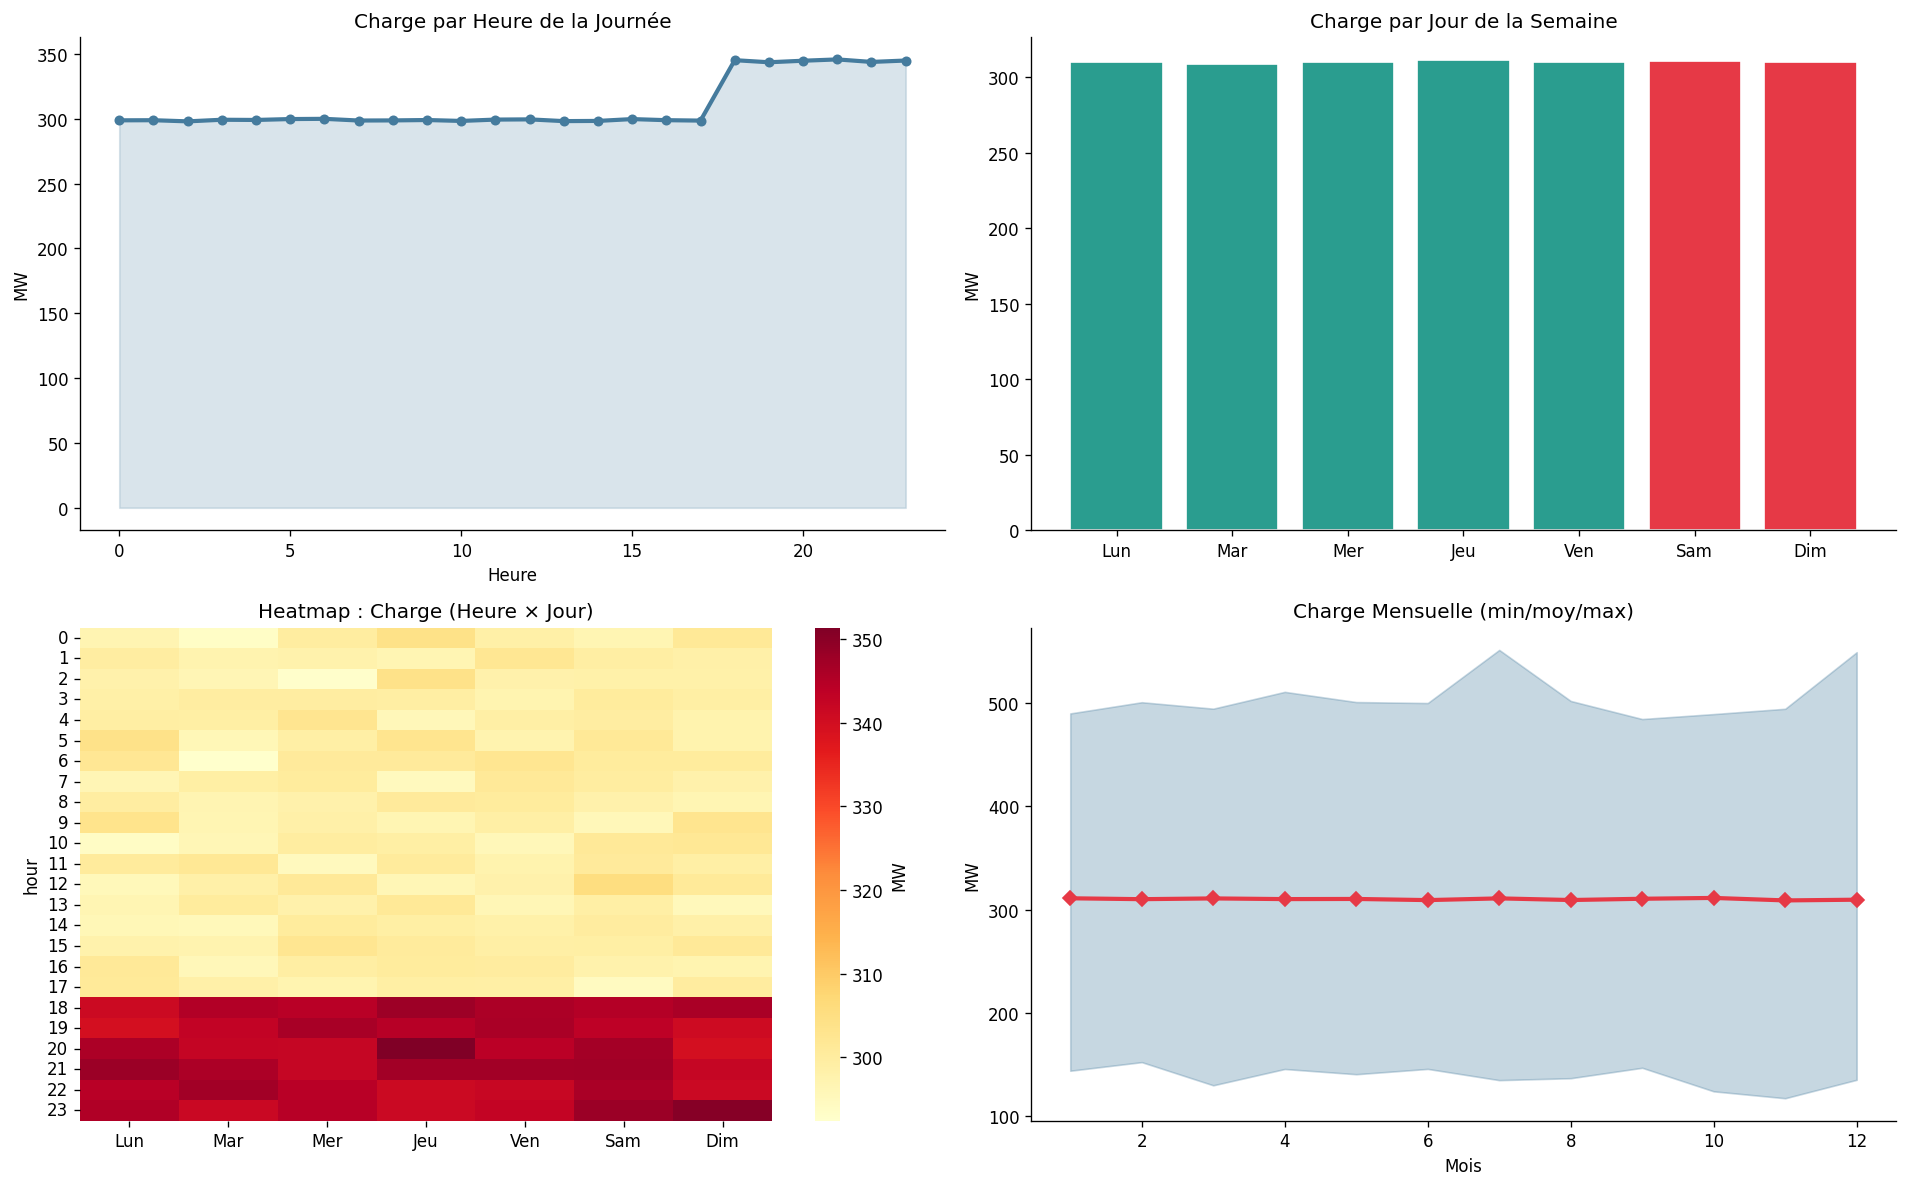

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Heure
hourly = df.groupby('hour')['total_load_mw'].mean()
axes[0,0].plot(hourly.index, hourly.values, '#457B9D', linewidth=2.5, marker='o', ms=5)
axes[0,0].fill_between(hourly.index, hourly.values, alpha=0.2, color='#457B9D')
axes[0,0].set_title('Charge par Heure de la Journée')
axes[0,0].set_xlabel('Heure')
axes[0,0].set_ylabel('MW')

# Jour de semaine
dow = df.groupby('day_of_week')['total_load_mw'].mean()
jours = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
axes[0,1].bar(jours, dow.values, color=['#2A9D8F']*5 + ['#E63946']*2, edgecolor='white')
axes[0,1].set_title('Charge par Jour de la Semaine')
axes[0,1].set_ylabel('MW')

# Heatmap heure x jour
pivot = df.pivot_table('total_load_mw', 'hour', 'day_of_week', aggfunc='mean')
pivot.columns = jours
sns.heatmap(pivot, ax=axes[1,0], cmap='YlOrRd', annot=False, cbar_kws={'label':'MW'})
axes[1,0].set_title('Heatmap : Charge (Heure × Jour)')


# Mensuel
if 'month' in df.columns:
    monthly = df.groupby('month')['total_load_mw'].agg(['mean','max','min'])
    axes[1,1].fill_between(monthly.index, monthly['min'], monthly['max'], alpha=0.3, color='#457B9D')
    axes[1,1].plot(monthly.index, monthly['mean'], '#E63946', linewidth=2.5, marker='D', ms=6)
    axes[1,1].set_title('Charge Mensuelle (min/moy/max)')
    axes[1,1].set_xlabel('Mois')
    axes[1,1].set_ylabel('MW')

plt.tight_layout()
plt.savefig(FIGURES / 'eda_temporal_patterns.png', bbox_inches='tight', dpi=120)
plt.show()

### 3.3 Matrice de Corrélation

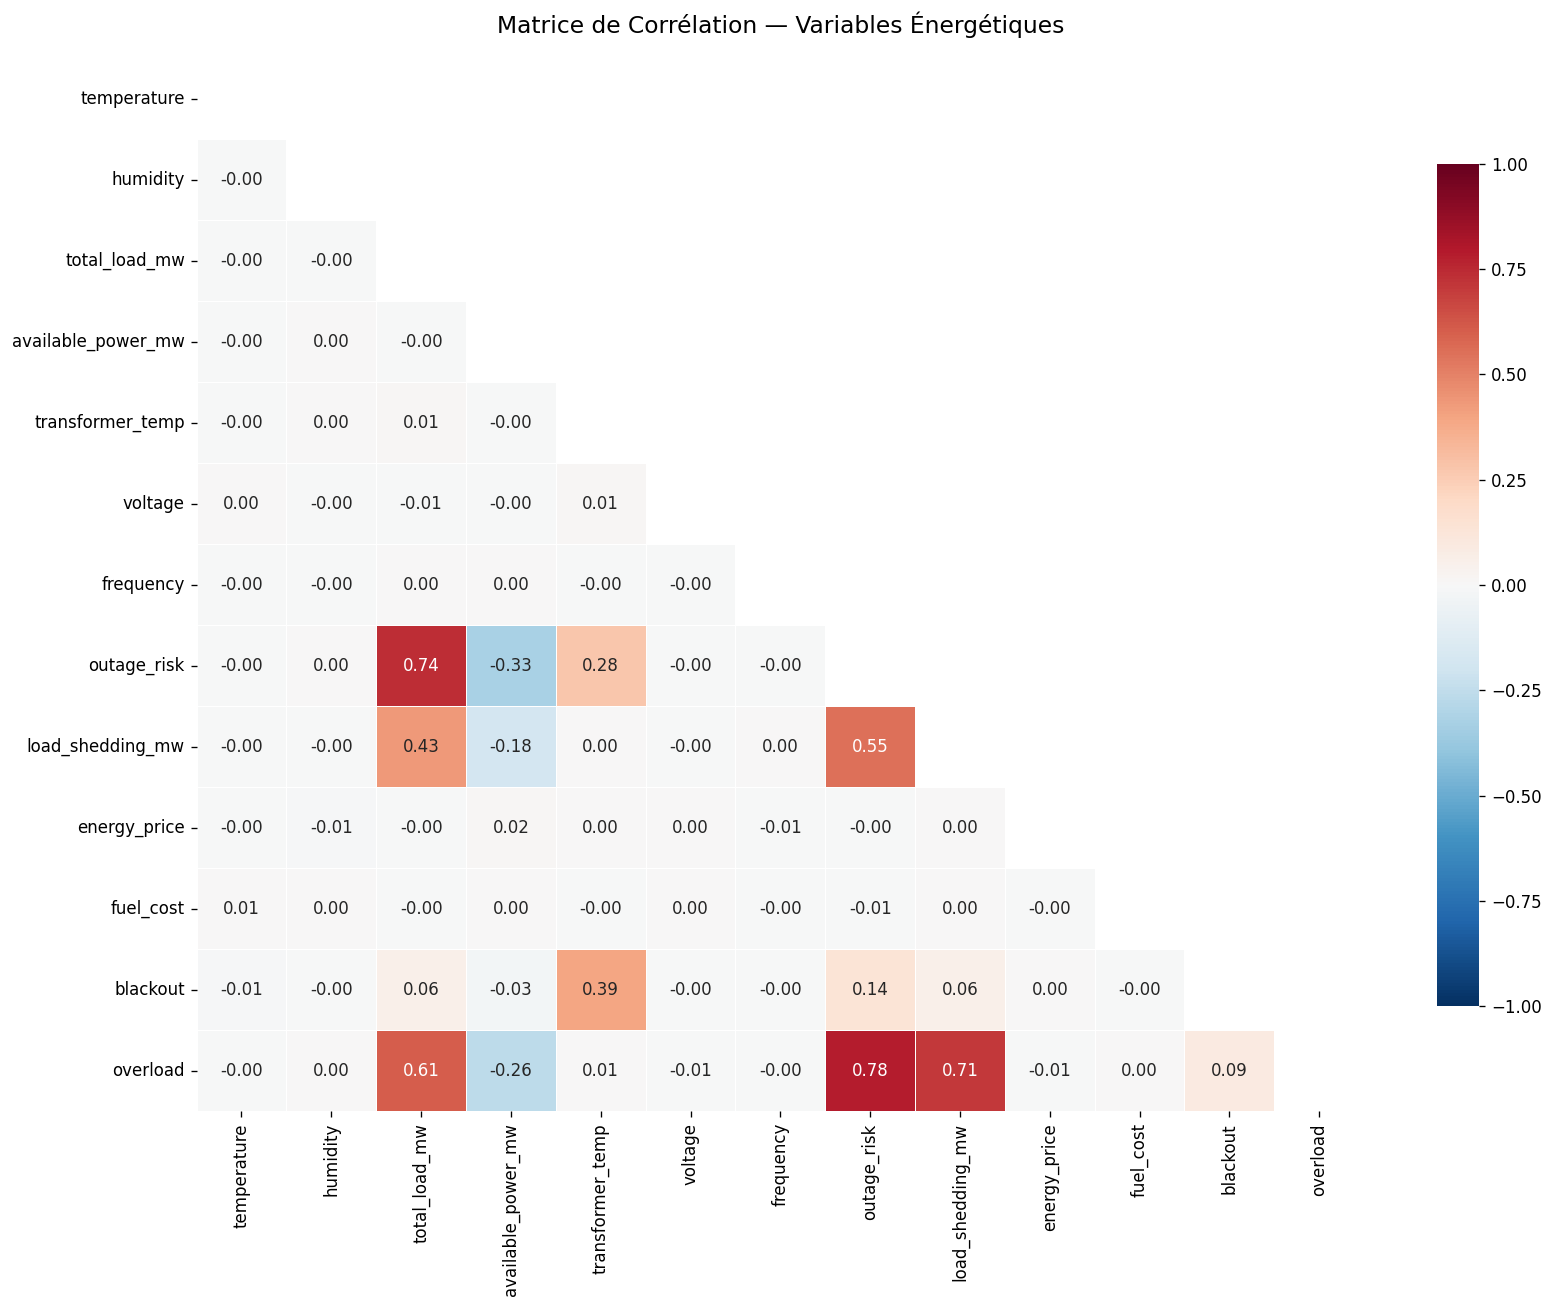

Top corrélations avec 'blackout' :
blackout            1.000000
transformer_temp    0.393956
outage_risk         0.137768
overload            0.093502
load_shedding_mw    0.061971
total_load_mw       0.061403
energy_price        0.004609
fuel_cost          -0.001066
humidity           -0.001383
voltage            -0.001586
Name: blackout, dtype: float64


In [17]:
num_cols = ['temperature','humidity','total_load_mw','available_power_mw',
            'transformer_temp','voltage','frequency','outage_risk',
            'load_shedding_mw','energy_price','fuel_cost','blackout','overload']
avail = [c for c in num_cols if c in df.columns]
corr = df[avail].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matrice de Corrélation — Variables Énergétiques', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(FIGURES / 'eda_correlation_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

print("Top corrélations avec 'blackout' :")
print(corr['blackout'].sort_values(ascending=False).head(10))

### 3.4 Analyse des Surcharges et Coupures

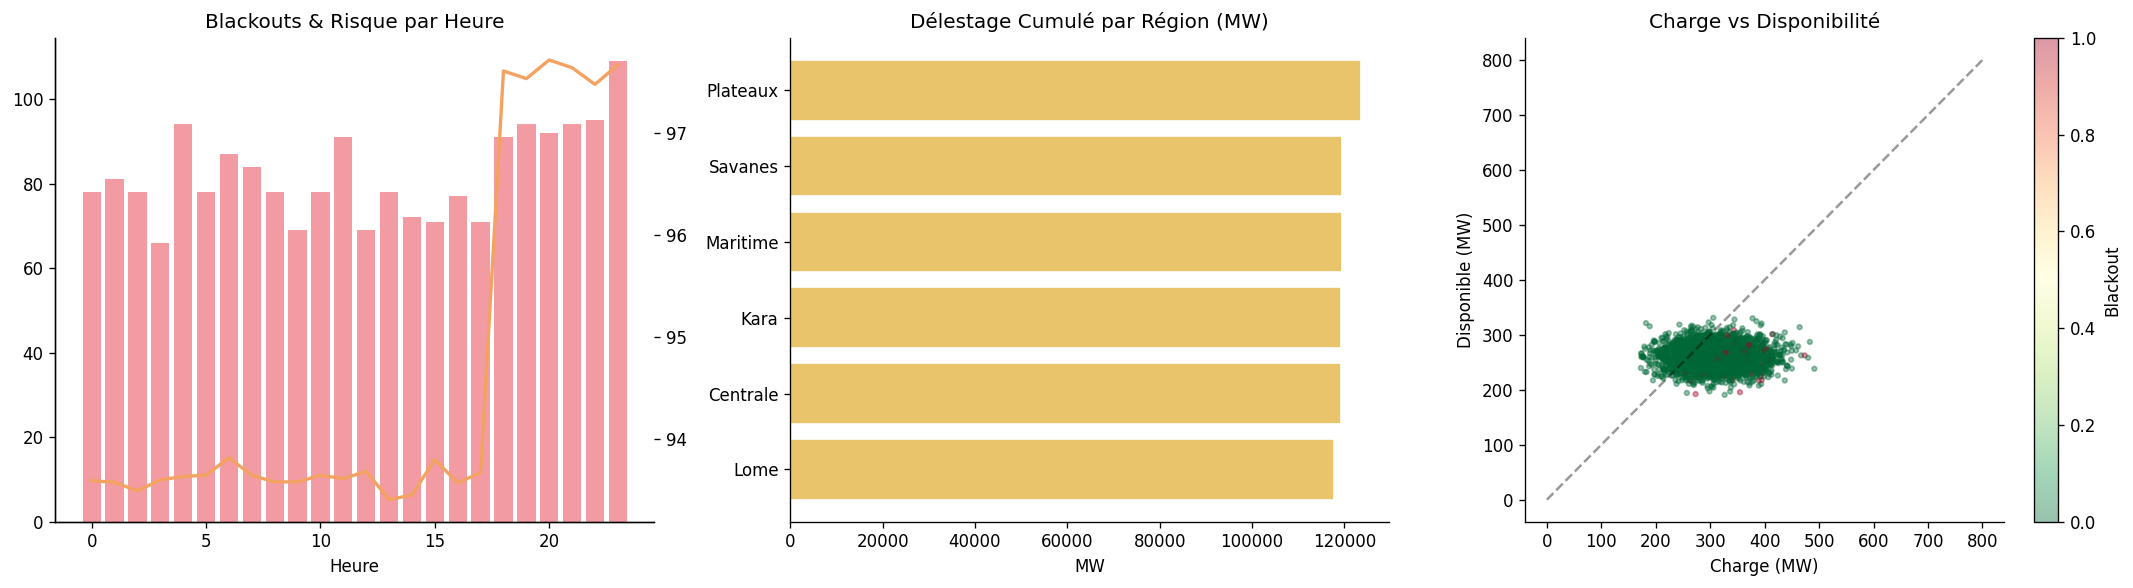

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Risque par heure
hourly_risk = df.groupby('hour').agg(risk=('outage_risk','mean'), blackouts=('blackout','sum'))
ax2 = axes[0].twinx()
axes[0].bar(hourly_risk.index, hourly_risk['blackouts'], color='#E63946', alpha=0.5, label='Blackouts')
ax2.plot(hourly_risk.index, hourly_risk['risk'], '#F4A261', linewidth=2, label='Risque moyen')
axes[0].set_title('Blackouts & Risque par Heure')
axes[0].set_xlabel('Heure')

# Délestage par région
shed = df.groupby('region')['load_shedding_mw'].sum().sort_values()
axes[1].barh(shed.index, shed.values, color='#E9C46A', edgecolor='white')
axes[1].set_title('Délestage Cumulé par Région (MW)')
axes[1].set_xlabel('MW')

# Pic de charge vs risque
sample = df.sample(min(3000, len(df)), random_state=42)
sc = axes[2].scatter(sample['total_load_mw'], sample['available_power_mw'],
                     c=sample['blackout'], cmap='RdYlGn_r', alpha=0.4, s=8)
plt.colorbar(sc, ax=axes[2], label='Blackout')
axes[2].plot([0,800],[0,800], 'k--', alpha=0.4)
axes[2].set_title('Charge vs Disponibilité')
axes[2].set_xlabel('Charge (MW)')
axes[2].set_ylabel('Disponible (MW)')

plt.tight_layout()
plt.savefig(FIGURES / 'eda_risk_analysis.png', bbox_inches='tight', dpi=120)
plt.show()

### 3.5 Analyse des Événements

In [19]:
event_stats = df.groupby('event').agg(
    n=('event','count'),
    avg_load=('total_load_mw','mean'),
    avg_risk=('outage_risk','mean'),
    blackout_rate=('blackout','mean'),
    avg_shedding=('load_shedding_mw','mean')
).round(2)

print("=== Impact des événements sur le réseau ===")
print(event_stats.sort_values('avg_risk', ascending=False))

fig = px.bar(event_stats.reset_index().sort_values('avg_risk', ascending=False),
             x='event', y=['avg_load','avg_risk'],
             barmode='group', title='Impact des Événements',
             template='plotly_white',
             color_discrete_map={'avg_load':'#457B9D','avg_risk':'#E63946'})
fig.show()

=== Impact des événements sur le réseau ===
                       n  avg_load  avg_risk  blackout_rate  avg_shedding
event                                                                    
Pas evenement      10065    311.19     94.75           0.04         14.46
Match de Football   9964    309.81     94.60           0.04         14.24
Event Politique    10046    310.60     94.59           0.04         14.44
Concert             9979    309.74     94.56           0.04         14.43
Festivale           9946    310.30     94.54           0.04         14.30


### 3.6 Grid Stress Index — Indicateur Composite

C:\Users\HP\AppData\Local\Temp\ipykernel_11608\2551373349.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stress_bl = df.groupby(pd.cut(df['grid_stress_index'],5))['blackout'].mean()*100


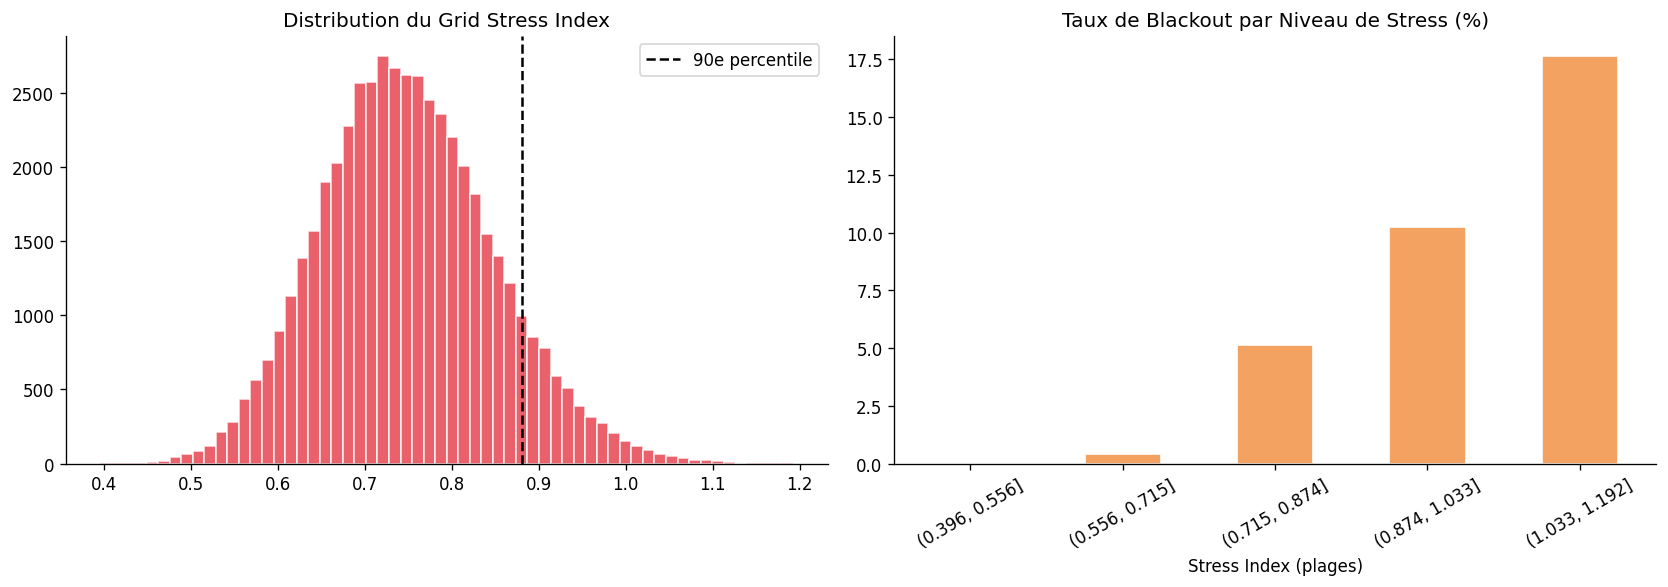

In [20]:
if 'grid_stress_index' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(df['grid_stress_index'], bins=60, color='#E63946', edgecolor='white', alpha=0.8)
    axes[0].axvline(df['grid_stress_index'].quantile(0.90), color='black', linestyle='--', label='90e percentile')
    axes[0].set_title('Distribution du Grid Stress Index')
    axes[0].legend()

    stress_bl = df.groupby(pd.cut(df['grid_stress_index'],5))['blackout'].mean()*100
    stress_bl.plot.bar(ax=axes[1], color='#F4A261', edgecolor='white')
    axes[1].set_title('Taux de Blackout par Niveau de Stress (%)')
    axes[1].set_xlabel('Stress Index (plages)')
    axes[1].tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()